<a href="https://colab.research.google.com/github/pachterlab/cellsweep/blob/main/benchmarking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# try:
#     from cellsweep import denoise_count_matrix
# except ImportError:
#     print("cellsweep not found, installing...")
#     !pip install -U -q cellsweep[analysis]

In [2]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from cellsweep import denoise_count_matrix
import cellsweep.utils as cs_utils
import scipy.sparse as sp

cellsweep_dir = os.path.dirname(os.path.abspath(""))
rver_docker_workspace = "/home/ruser/work/cellsweep"

# Compare technologies

In [3]:
dataset_name = "smartseq_10x"  # options: parse_10x, smartseq_10x
verbose = 2  # 2 debug, 1 info, 0 warning, -1 error, -2 critical
overwrite = False  # overwrite existing files
threads = 32  # for cellsweep and CellBender (if use_cuda=False)
docker = "podman"  # "docker" or "podman" - if podman, then run `sudo setenforce 0` to disable SELinux enforcement before the podman commands

In [4]:
data_dir = os.path.join(cellsweep_dir, "notebooks", "data", dataset_name)
os.makedirs(data_dir, exist_ok=True)

out_dir = os.path.join(cellsweep_dir, "notebooks", "output", dataset_name)
os.makedirs(out_dir, exist_ok=True)

adata_10x_url, adata_parse_url, adata_smartseq_url = None, None, None
adata_path_raw_10x, adata_path_raw_parse, adata_path_raw_smartseq = None, None, None

adata_path_raw_smartseq = os.path.join(data_dir, "adata_smartseq_raw.h5ad")

technology_to_adata_raw, technology_to_adata_raw_path = {}, {}
if dataset_name == "parse_10x":
    technologies = ["10x", "parse"]
    
    adata_10x_url = "https://caltech.box.com/shared/static/g03q46wpr5uj81gqp0dh3dyy02zw200e.h5ad"
    adata_parse_url = "https://caltech.box.com/shared/static/4bai2qfe7xk2956ug1t7bpdw0q6tspie.h5ad"

    adata_path_raw_10x = os.path.join(data_dir, "adata_10x_raw.h5ad")
    adata_path_raw_parse = os.path.join(data_dir, "adata_parse_raw.h5ad")

    if not os.path.exists(adata_path_raw_10x):
        !wget -O {adata_path_raw_10x} {adata_10x_url}

    if not os.path.exists(adata_path_raw_parse):
        !wget -O {adata_path_raw_parse} {adata_parse_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["parse"] = adata_path_raw_parse

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["parse"] = ad.read_h5ad(adata_path_raw_parse)

    technology_to_umi_cutoff = {
        "10x": 300,
        "parse": 200,
    }
    technology_to_leiden_resolution = {
        "10x": 2.0,
        "parse": 2.5
    }

elif dataset_name == "smartseq_10x":  # https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE132044
    technologies = ["10x", "smartseq"]

    adata_path_raw_10x = os.path.join(data_dir, "10xv3_gene.h5ad")
    adata_path_raw_smartseq = os.path.join(data_dir, "smartseq_gene.h5ad")

    if not os.path.exists(adata_path_raw_10x) or not os.path.exists(adata_path_raw_smartseq):
        matrix_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_count_matrix.mtx.gz")
        cell_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_cell.tsv.gz")
        gene_path = os.path.join(data_dir, "GSE132044_mixture_hg19_mm10_gene.tsv.gz")
        
        if not os.path.exists(matrix_path):
            !wget -O {matrix_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fcount%5Fmatrix%2Emtx%2Egz"
        if not os.path.exists(cell_path):
            !wget -O {cell_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fcell%2Etsv%2Egz"
        if not os.path.exists(gene_path):
            !wget -O {gene_path} "https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSE132044&format=file&file=GSE132044%5Fmixture%5Fhg19%5Fmm10%5Fgene%2Etsv%2Egz"

        adata = sc.read_mtx(matrix_path)
        adata = adata.T

        genes = pd.read_csv(gene_path, header=None, sep="\t")
        adata.var_names = genes[0].values

        barcodes = pd.read_csv(cell_path, header=None, sep="\t")
        adata.obs_names = barcodes[0].values

        adata.obs[["mixture", "protocol", "plate_well"]] = (
            adata.obs.index
            .to_series()
            .str.split(".", expand=True)
        )

        adata_smartseq = adata[adata.obs['protocol'] == 'Smart-seq2'].copy()
        adata_10x = adata[adata.obs['protocol'] == '10x-Chromium-v2'].copy()

        # save
        adata_smartseq.write_h5ad(adata_path_raw_smartseq)
        adata_10x.write_h5ad(adata_path_raw_10x)

    # if not os.path.exists(adata_path_raw_10x):
    #     !wget -O {adata_path_raw_10x} {adata_10x_url}

    # if not os.path.exists(adata_path_raw_smartseq):
    #     !wget -O {adata_path_raw_smartseq} {adata_smartseq_url}

    technology_to_adata_raw_path["10x"] = adata_path_raw_10x
    technology_to_adata_raw_path["smartseq"] = adata_path_raw_smartseq

    technology_to_adata_raw["10x"] = ad.read_h5ad(adata_path_raw_10x)
    technology_to_adata_raw["smartseq"] = ad.read_h5ad(adata_path_raw_smartseq)

    technology_to_umi_cutoff = {
        "10x": None,
        "smartseq": None,
    }
    technology_to_leiden_resolution = {
        "10x": 1.0,
        "smartseq": 1.0
    }
else:
    raise ValueError(f"dataset_name {dataset_name} not recognized.")

technology0, technology1 = technologies[0], technologies[1]

## Knee plot - use this output to estimate umi_cutoff

In [5]:
technology_to_adata_raw

{'10x': AnnData object with n_obs × n_vars = 6346 × 62046
     obs: 'mixture', 'protocol', 'plate_well',
 'smartseq': AnnData object with n_obs × n_vars = 685 × 62046
     obs: 'mixture', 'protocol', 'plate_well'}

Processing technology: 10x
Processing technology: smartseq


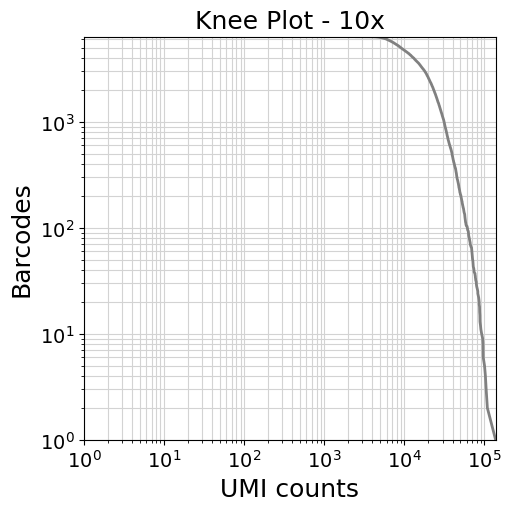

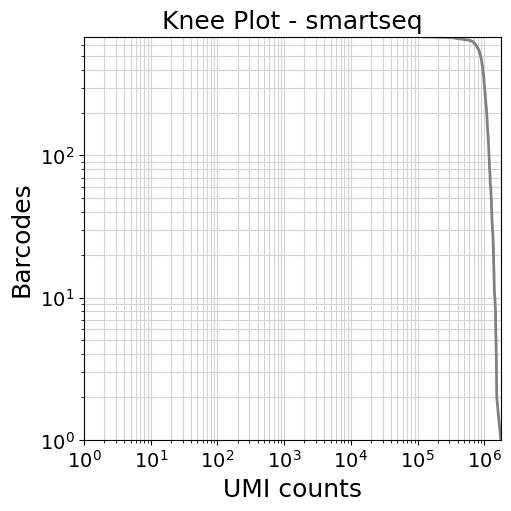

In [6]:
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Processing technology: {technology}")
    _ = cs_utils.knee_plot(adata_raw, transpose=True, title=f"Knee Plot - {technology}", out_path=os.path.join(out_dir, f"knee_plot_{technology}.png"))

In [7]:
# technology_to_umi_cutoff = {}   #!!! update

In [8]:
for technology, adata_raw in technology_to_adata_raw.items():
    if dataset_name == "smartseq_10x":  # technology == "smartseq"
        print(f"Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)")  # print(f"Skipping empty droplet inference for technology: {technology} (each barcode is a cell)")

        adata_raw.obs["is_empty"] = False
        adata_raw.var['empty_counts'] = 0
        technology_to_adata_raw[technology] = adata_raw
        
        continue

    print(f"Inferring empty droplets for technology: {technology}")
    #$ (1) UMI threshold
    # umi_cutoff = technology_to_umi_cutoff[technology]
    # adata_raw = cs_utils.infer_empty_droplets(adata_raw, method="threshold", umi_cutoff=umi_cutoff, verbose=verbose)  # adds adata.obs["is_empty"]

    #$ (2) EmptyDrops
    parent_dir = technology_to_adata_raw_path[technology].replace(".h5ad", "_raw_dir")
    paths = cs_utils.write_10x_like(adata_raw, parent_dir, gzip_output=True, is_empty_col="is_empty", cluster_col=None, write_raw=True, write_filtered=False)
    raw_tar_file_dir = paths["raw"]

    emptydrops_barcodes_file = os.path.join(data_dir, f"emptydrops_barcodes_{technology}.txt")
    if not os.path.exists(emptydrops_barcodes_file) or overwrite:
        !{docker} run --rm \
            -w /home/ruser/work \
            -v {cellsweep_dir}:{rver_docker_workspace} \
            josephrich98/cellsweep_tutorials:decontx.0.1.0 \
            Rscript {rver_docker_workspace}/scripts/run_emptydrops.R \
                {raw_tar_file_dir.replace(cellsweep_dir, rver_docker_workspace)} \
                {emptydrops_barcodes_file.replace(cellsweep_dir, rver_docker_workspace)}

    with open(emptydrops_barcodes_file) as f:
        emptydrops_cellular_barcodes = set(line.strip() for line in f)

    adata_raw.obs["is_empty"] = ~adata_raw.obs.index.isin(emptydrops_cellular_barcodes)

    adata_raw.var['empty_counts'] = np.array(adata_raw.X[adata_raw.obs['is_empty'].values, :].sum(axis=0)).flatten()
    technology_to_adata_raw[technology] = adata_raw

Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)
Skipping empty droplet inference for dataset_name: smartseq_10x (filtered data only)


## cellsweep

In [9]:
technology_to_adata_cellsweep, technology_to_adata_cellsweep_empty_barcodes = {}, {}
for technology, adata_raw in technology_to_adata_raw.items():
    print(f"Denoising counts for technology: {technology}")
    adata_path_cellsweep = os.path.join(data_dir, f"adata_cellsweep_{technology}.h5ad")
    cellsweep_log_file = os.path.join(data_dir, f"cellsweep_{technology}.log")
    freeze_ambient_profile = False if dataset_name == "smartseq_10x" else True  # False if technology == "smartseq" else True
    
    if not os.path.exists(adata_path_cellsweep) or overwrite:
        adata = adata_raw.copy()
        if "celltype" not in adata.obs.columns:
            if dataset_name == "smartseq_10x":
                if "genome" not in adata.obs.columns:
                    adata = cs_utils.identify_human_and_mouse_cells(adata, human_prefix="hg19_", mouse_prefix="mm10_")
                adata.obs['celltype'] = adata.obs['genome']
            else:
                leiden_resolution = technology_to_leiden_resolution[technology]
                adata_processed_tmp = adata[~adata.obs["is_empty"]].copy()
                adata_processed_tmp = cs_utils.run_scanpy_preprocessing_and_clustering(adata_processed_tmp, min_genes=None, min_cells=None, max_mt_percentage=None, n_top_genes=2000, n_pcs=50, n_neighbors=15, leiden_resolution=leiden_resolution, seed=42, verbose=verbose)
                adata.obs["celltype"] = adata_processed_tmp.obs["leiden"].reindex(adata.obs.index).astype(str).replace("nan", "empty").astype("category")
        adata_cellsweep = denoise_count_matrix(adata, init_alpha = 0.9, beta = 0.1, adata_out=adata_path_cellsweep, freeze_ambient_profile=freeze_ambient_profile, max_iter=1500, empty_droplet_method="threshold", threads=threads, verbose=verbose, log_file=cellsweep_log_file)
    else:
        print(f"Loading existing cellsweep denoised data for technology: {technology}")
        adata_cellsweep = ad.read_h5ad(adata_path_cellsweep)
    
    adata_cellsweep_empty_barcodes = adata_cellsweep[adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep_empty_barcodes.var_names_make_unique()
    technology_to_adata_cellsweep_empty_barcodes[technology] = adata_cellsweep_empty_barcodes

    adata_cellsweep = adata_cellsweep[~adata_cellsweep.obs["is_empty"]].copy()
    adata_cellsweep.var_names_make_unique()
    
    technology_to_adata_cellsweep[technology] = adata_cellsweep

Denoising counts for technology: 10x
Loading existing cellsweep denoised data for technology: 10x
Denoising counts for technology: smartseq
Loading existing cellsweep denoised data for technology: smartseq


## Analysis

### Raw vs cellsweep knee plot, scatterplots

Technology: 10x


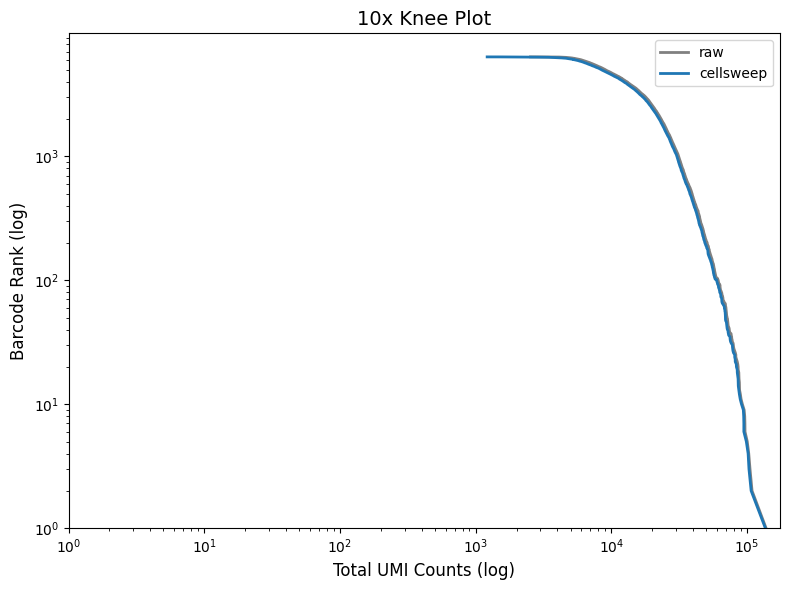

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


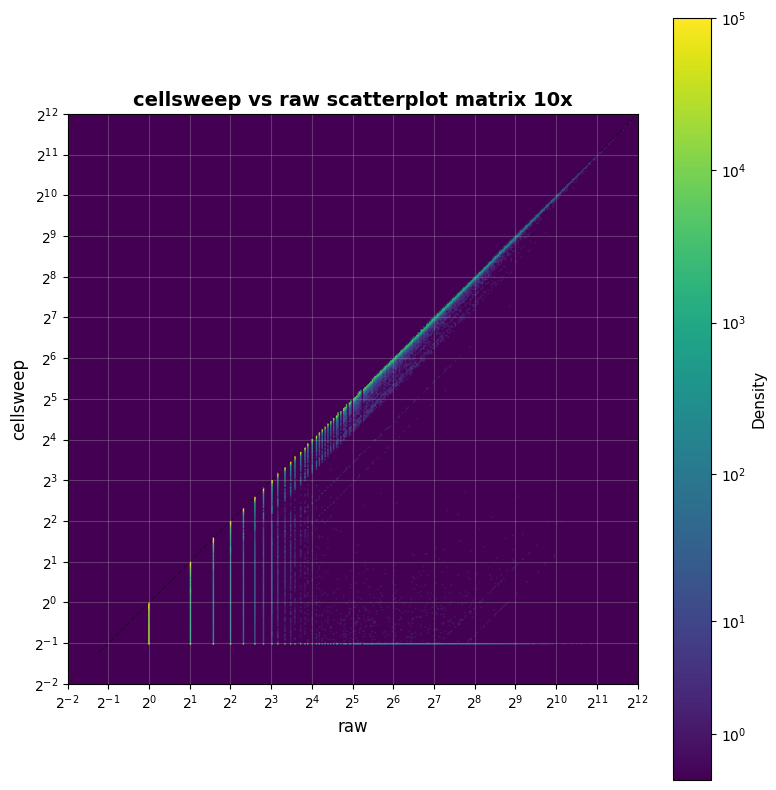

Creating scatterplot...
Calculating scatterplot...


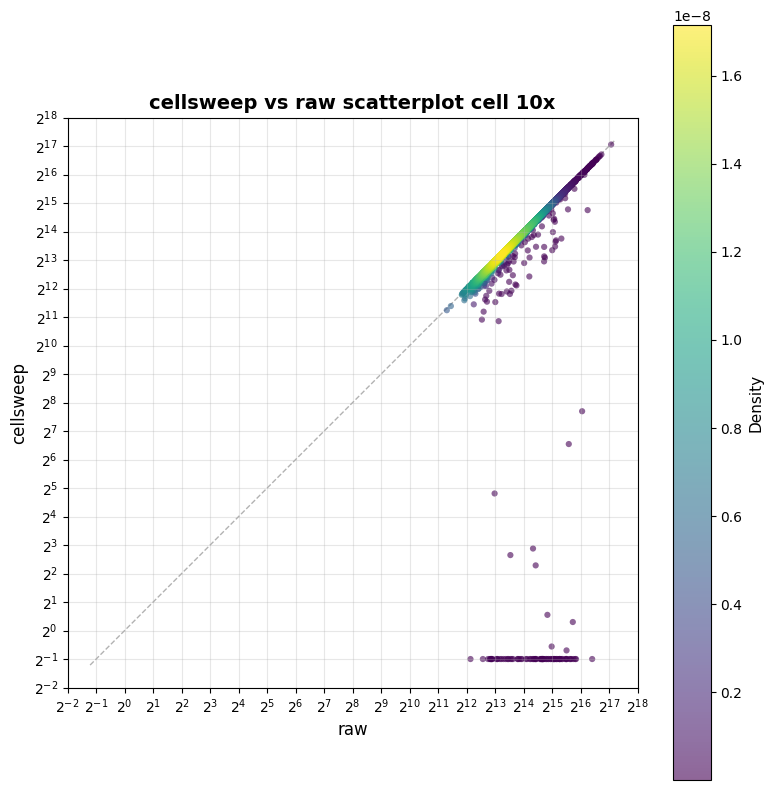

Creating scatterplot...
Calculating scatterplot...


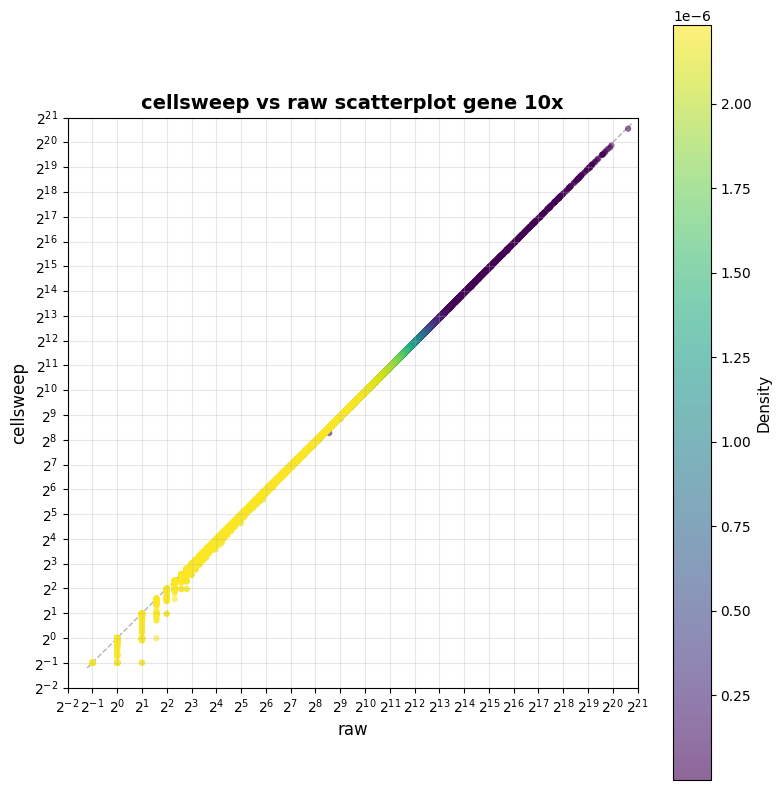

Technology: smartseq


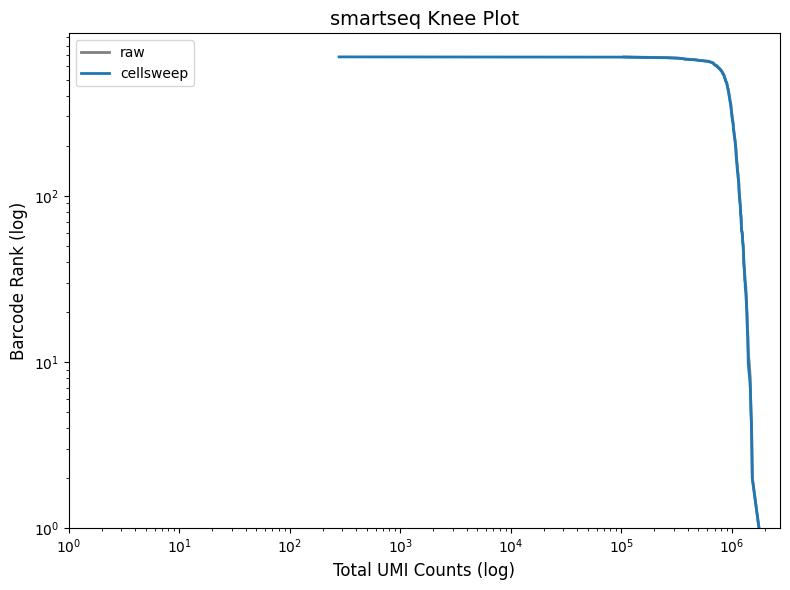

Extracting all nonzero pairs from sparse matrices...
Creating scatterplot...
Calculating scatterplot...


/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:77: RuntimeWarning: All-NaN slice encountered
  vmin = self._density_vmin(array)
/home/jrich/miniconda3/envs/cellsweep/lib/python3.10/site-packages/mpl_scatter_density/generic_density_artist.py:82: RuntimeWarning: All-NaN slice encountered
  vmax = self._density_vmax(array)


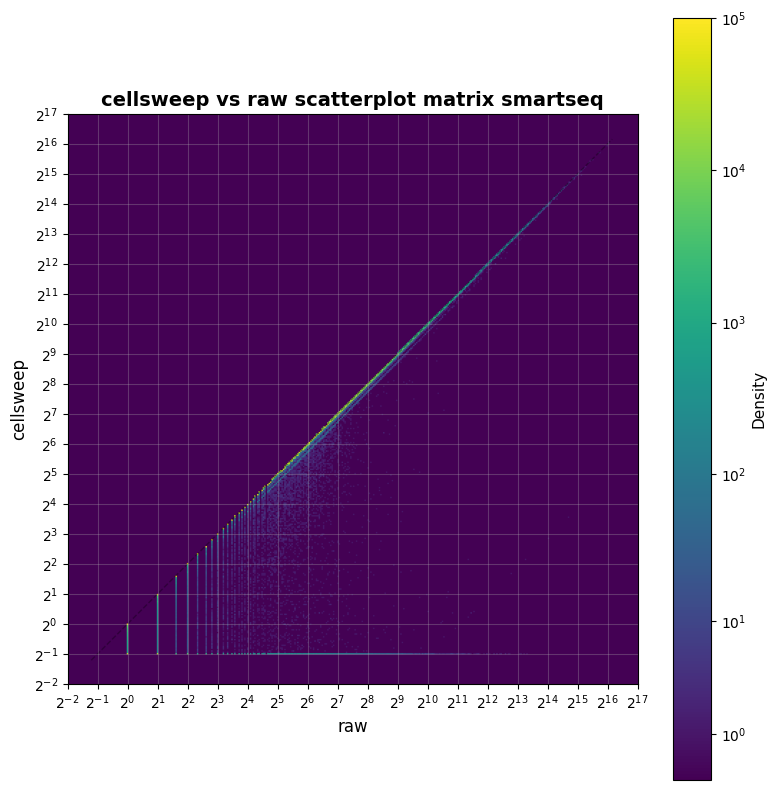

Creating scatterplot...
Calculating scatterplot...


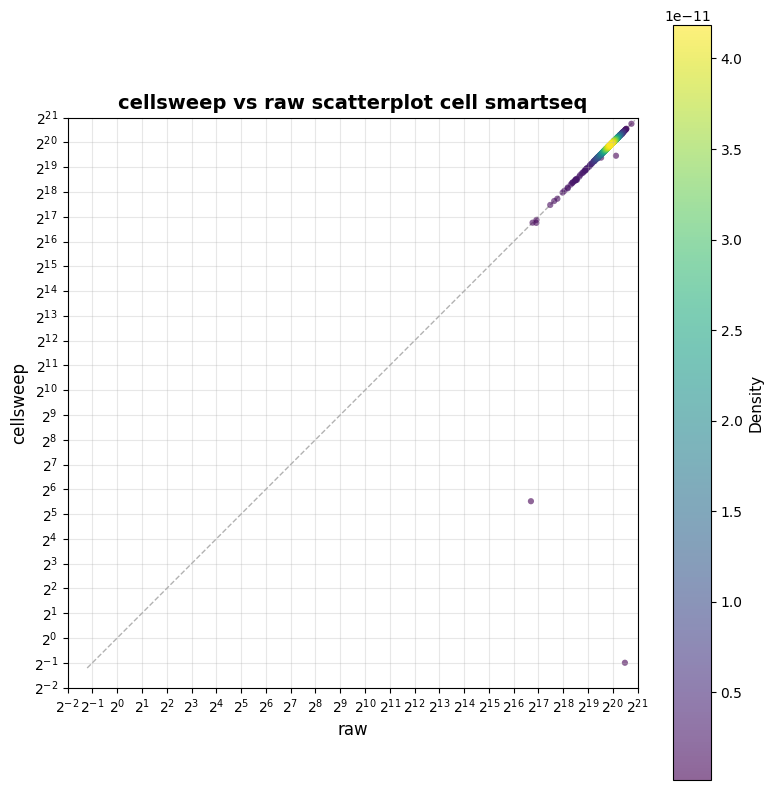

Creating scatterplot...
Calculating scatterplot...


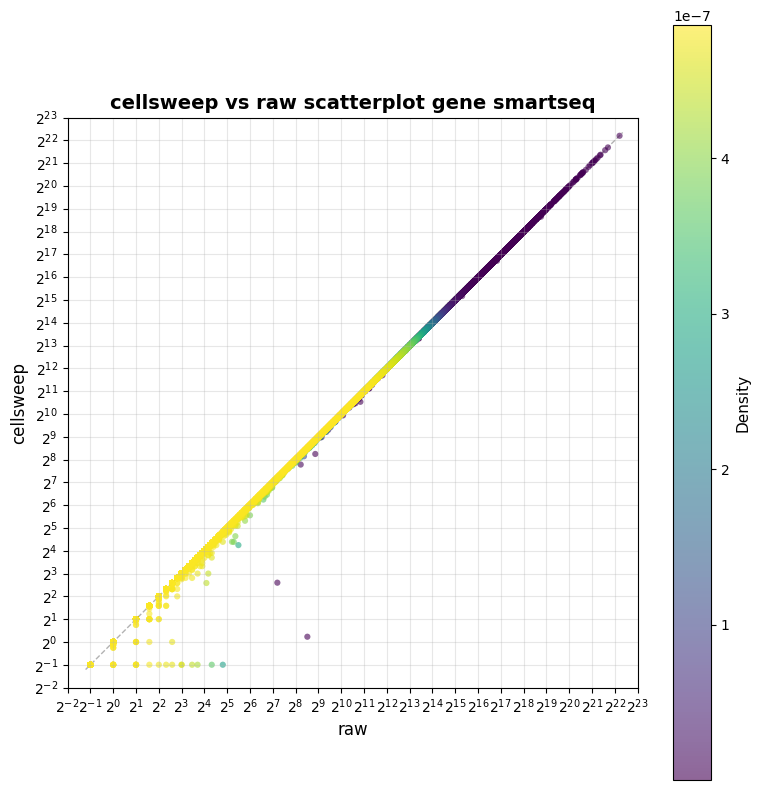

In [10]:
for technology in technologies:
    print(f"Technology: {technology}")
    adata_raw = technology_to_adata_raw[technology]
    adata_cellsweep = technology_to_adata_cellsweep[technology]
    cs_utils.plot_knee_multi([adata_raw, adata_cellsweep], labels=["raw", "cellsweep"], title=f"{technology} Knee Plot", filter_empty=True, transpose=True, out_path=os.path.join(out_dir, f"{technology}_knee_plot.png"))

    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="matrix", density_type="scatter_with_density", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot matrix {technology}", out_path=os.path.join(out_dir, f"{technology}_matrix_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="cell", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot cell {technology}", out_path=os.path.join(out_dir, f"{technology}_cell_expression_scatterplot.png"), show=True)
    cs_utils.plot_matrix_scatterplot(adata_raw, adata_cellsweep, point_type="gene", density_type="scatter_with_kde", scale="log", x_axis="raw", y_axis="cellsweep", title=f"cellsweep vs raw scatterplot gene {technology}", out_path=os.path.join(out_dir, f"{technology}_gene_expression_scatterplot.png"), show=True)

### Ambient hat per gene scatterplot across technologies

Creating scatterplot...
Calculating scatterplot...


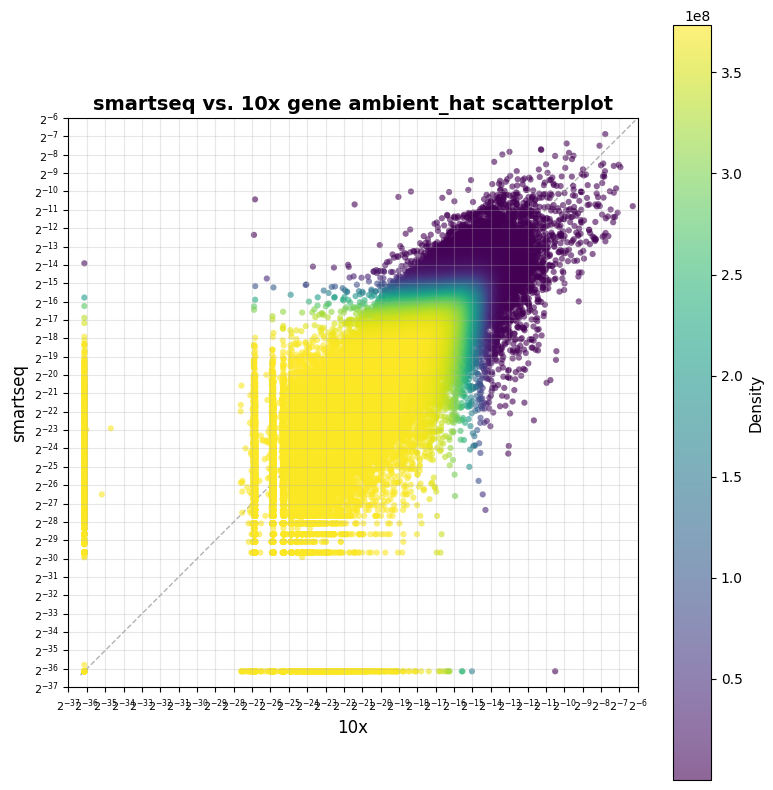

In [11]:
s = technology_to_adata_cellsweep[technology0].var["ambient_hat"]
nonzero_min = s[s > 0].min()
cs_utils.plot_matrix_scatterplot(technology_to_adata_cellsweep[technology0].var["ambient_hat"], technology_to_adata_cellsweep[technology1].var["ambient_hat"], minimum=nonzero_min, point_type="custom", density_type="scatter_with_kde", scale="log", title=f"{technology1} vs. {technology0} gene ambient_hat scatterplot", x_axis=technology0, y_axis=technology1, tick_labelsize=8, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_ambient_hat_scatterplot.png"), show=True)

### Ambient fraction per cell histogram across technologies

10x cell contamination AUC: 63.23132751220475
smartseq cell contamination AUC: 6.85


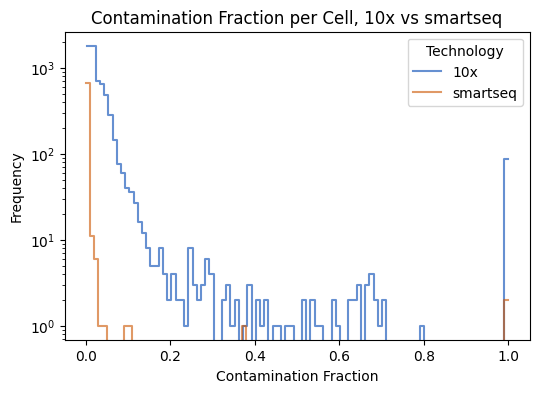

In [12]:
cs_utils.plot_multi_histogram(technology_to_adata_cellsweep[technology0].obs, technology_to_adata_cellsweep[technology1].obs, plotting_column="alpha_hat", df1_name=technology0, df2_name=technology1, out_path=os.path.join(out_dir, f"{technology0}_vs_{technology1}_cell_empty_fraction_histogram.png"), show=True)

Technology: 10x
cellsweep human cell mouse gene contamination AUC: 14061.352680206299
cellsweep mouse cell human gene contamination AUC: 8745.22549533844


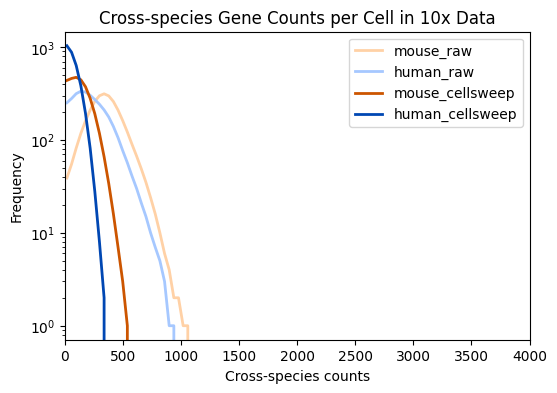

Technology: smartseq
cellsweep human cell mouse gene contamination AUC: 12039.461658477783
cellsweep mouse cell human gene contamination AUC: 28869.125686645508


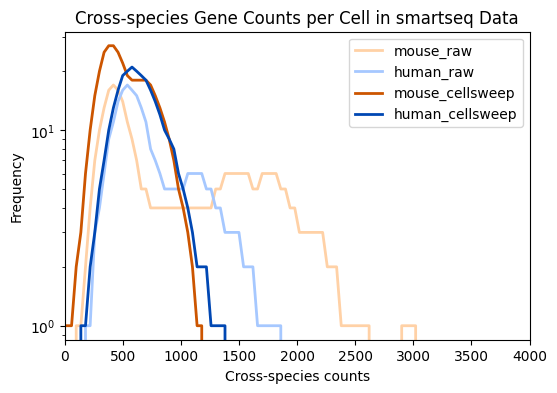

In [18]:
if dataset_name == "smartseq_10x":
    def identify_human_and_mouse_cells_here(adata):
        if "human_counts_total_" in adata.obs.columns and "mouse_counts_total_" in adata.obs.columns and "genome" in adata.obs.columns:
            return adata  # already identified
        
        # for adata.var['genome']: if it starts with mm10 --> mm10, elif starts with hg19 --> hg19, else unknown
        def map_genome(gene_name):
            if gene_name.startswith("ENSMUS") or gene_name.endswith("_mm10") or gene_name.startswith("mm10"):
                return "mm10"
            elif gene_name.startswith("ENSG") or gene_name.endswith("_hg19") or gene_name.startswith("hg19"):
                return "hg19"
            else:
                return "unknown"

        if 'genome' not in adata.var.columns:
            adata.var['genome'] = adata.var_names.map(map_genome)
        
        if "unknown" in adata.var['genome'].values:
            print("Warning: some genes have unknown genome assignment.")
        
        is_human = (adata.var["genome"] == "hg19").values
        is_mouse = (adata.var["genome"] == "mm10").values
        adata.obs["human_counts_total_"] = np.array(adata.X[:, is_human].sum(axis=1)).ravel()
        adata.obs["mouse_counts_total_"] = np.array(adata.X[:, is_mouse].sum(axis=1)).ravel()
        adata.obs['genome'] = np.where(adata.obs['human_counts_total_'] >= adata.obs['mouse_counts_total_'], 'human', 'mouse')  # predict genome
        return adata

    for technology in technologies:
        print(f"Technology: {technology}")
        adata_raw = technology_to_adata_raw[technology].copy()
        adata_cellsweep = technology_to_adata_cellsweep[technology].copy()

        # drop duplicate calculation (would conflict with plot_cross_species_histogram)
        if "human_counts_total" in adata_cellsweep.obs.columns:
            adata_cellsweep.obs.drop(columns=[col for col in ["human_counts_total", "mouse_counts_total", "genome"] if col in adata_cellsweep.obs.columns], inplace=True)

        adata_raw = identify_human_and_mouse_cells_here(adata_raw)
        adata_cellsweep = identify_human_and_mouse_cells_here(adata_cellsweep)

        adata_raw.obs["total_counts"] = adata_raw.obs["human_counts_total_"] + adata_raw.obs["mouse_counts_total_"]
        adata_raw.obs["frac_human"] = adata_raw.obs["human_counts_total_"] / adata_raw.obs["total_counts"]
        adata_raw.obs["frac_mouse"] = 1 - adata_raw.obs["frac_human"]
        fraction_doublet = 0.10
        adata_raw.obs["is_doublet"] = (adata_raw.obs["frac_human"] > fraction_doublet) & (adata_raw.obs["frac_human"] < (1 - fraction_doublet))
        adata_raw_no_doublets = adata_raw[~adata_raw.obs["is_doublet"]].copy()
        doublet_cell_set = set(adata_raw.obs_names[adata_raw.obs["is_doublet"]])

        cs_utils.plot_cross_species_histogram(adata_cellsweep, adata_raw=adata_raw_no_doublets, processed_name="cellsweep", doublet_cell_set=doublet_cell_set, xmax=4_000, kind="smooth", title = f"Cross-species Gene Counts per Cell in {technology} Data", out_path=os.path.join(out_dir, f"{technology}_cellsweep_human_mouse_contamination_histograms_by_cells.png"))
        # cs_utils.plot_cross_species_joint_scatterplot(adata_raw_no_doublets, adata_cellsweep, processed_name="cellsweep", x_name="human", y_name="mouse", x_axis="human_counts_total_", y_axis="mouse_counts_total_", genome_column="genome", marginal_type="histogram", fill_histogram=False, show_marginal_ticks=True, show_point_movement=True, out_path=os.path.join(out_dir, f"{technology}_human_mouse_cellsweep_joint_scatterplot.png"), show=True)